# Experiments on Arbitrary Routes
This notebook contains experiments that build intuition about the effects of various holding policies and stop placements in a route.

In [1]:
from copy import deepcopy
from dataclasses import dataclass
from os import path

from plotly import express, graph_objects, subplots

from analysis.policies import *
from analysis.routes import *
from analysis.prob_analysis import *
from analysis.wc_analysis import *

## Plotting Helpers

In [2]:
@dataclass
class RouteConfig(object):
    """Configuration information that defines a route variant under test.
    
    :param name: Name used for identification.
    :param route: List of stops.
    :param start_times: List of times when vehicles start serving the route.
    """ 
    name: str
    route: list[Stop]
    start_times: list[float]

In [3]:
@dataclass
class HeadwayResults(object):
    """Headway experiment results.
    
    :param upper_bound: List of maximum possible headway at each stop.
    :param lower_bound: List of minimum possible headway at each stop.
    :param observed: List of headway times observed during simulation at each stop.
    """ 
    upper_bound: list[float]
    lower_bound: list[float]
    observed: list[list[float]]

In [4]:
@dataclass
class RouteResults(object):
    """Results from an experiment on one route variant.
    
    :param name: Name used for identification.
    :param route: The route under consideration.
    :param headway: Simulated and analytical headway results for the route.
    :param travel_time: Measured travel times between all pairs of stops.
    """ 
    name: str
    route: list[Stop]
    headway: HeadwayResults
    travel_time: list[list[list[float]]]

In [5]:
def plot_headway(exp_id: str, results: list[RouteResults]) -> None:
    """Plot simulated and analytical headway bounds.

    :param exp_id: Experiment name used used when saving the figure.
    :param results: List of results for each route under consideration.
    """
    fig = graph_objects.Figure()
    whitespace = 0.2
    width = (1 - whitespace) / len(results)

    for i, result in enumerate(results):
        offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width

        for stop_idx in range(len(result.route)):
            fig.add_trace(graph_objects.Bar(
                base=[result.headway.lower_bound[stop_idx]],
                legend='legend1',
                marker={'color': express.colors.qualitative.T10[i]},
                marker_pattern_shape='x',
                name='$' + result.name + r'\textrm{ (Bounds)}' + '$',
                opacity=0.5,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset],
                y=[result.headway.upper_bound[stop_idx]],
            ))
            fig.add_trace(graph_objects.Box(
                legend='legend2',
                marker={'color': express.colors.qualitative.T10[i]},
                name='$' + result.name + r'\textrm{ (Sim.)}' + '$',
                opacity=1.0,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset] * len(result.headway.observed[stop_idx]),
                y=result.headway.observed[stop_idx],
            ))

    fig.update_layout(
        # General style
        font_family='Times New Roman, serif',
        plot_bgcolor='white',

        # Dimensions
        height=360,
        width=750,

        # Axes
        xaxis=dict(
            side='top',
            tickmode='array',
            tickvals=[j for j in range(max([len(r.route) for r in results]))],
            title='Stop #',
            title_standoff=0.0,
        ),
        yaxis=dict(
            gridcolor='lightgrey',
            showgrid=True,
            title='Headway Time (min.)',
            title_standoff=0.0,
            zeroline=True,
            zerolinecolor='lightgrey',
        ),

        # Legends
        legend1=dict(
            orientation='v',
            x=0.25,
            xanchor='center',
            y=-0.15 * len(results),
            yanchor='bottom',
        ),
        legend2=dict(
            orientation='v',
            x=0.75,
            xanchor='center',
            y=-0.15 * len(results),
            yanchor='bottom',
        ),
    )

    fig.show()
    fig.write_image(path.join('figures', f'{exp_id}.pdf'))

In [6]:
def plot_travel(results: list[RouteResults]):
    """Plot in-vehice travel time for the simulated route.

    :param results: List of results for each route under consideration.
    """
    fig = subplots.make_subplots(
        cols=len(results),
        column_titles=['$' + r.name + '$' for r in results],
        rows=1,
        x_title='To Stop #',
        y_title='Worst Case<br>Travel Time From Stop #',
    )

    # Normalize Color Scales
    absolute_max = 0
    absolute_min = float('inf')
    for result in results:
        for i in result.travel_time:
            for j in i:
                absolute_max = max(absolute_max, max(j))
                absolute_min = min(absolute_min, min(j))
    
    # Plot The Thing
    for idx, result in enumerate(results):
        z=[[max(k) for k in j] for j in result.travel_time]
        fig.add_trace(
            graph_objects.Heatmap(
                showscale=False,
                text=z,
                texttemplate='%{text:.0f}',
                z=z,
                zmax=absolute_max,
                zmin=absolute_min,
            ),
            col=idx + 1,
            row=1,
        )

        tickvals = [i for i, _ in enumerate(result.route)]
        ticktext = [str(i) for i in tickvals]
        layout_kwargs = {
            f'xaxis{idx + 1}': dict(tickvals=tickvals, ticktext=ticktext),
            f'yaxis{idx + 1}': dict(tickvals=tickvals, ticktext=ticktext),
        }
        fig.update_layout(**layout_kwargs)

    fig.show()

In [7]:
def run_experiment(exp_id: str, routes: list[RouteConfig], t_max: float) -> None:
    """Run an experiment.

    :param exp_id: Experiment name.
    :param routes: The routes (including start times) to compare.
    :param t_max: The cutoff time for simulation and analytical analysis.
    """
    results = []
    for route in routes:
        print(f'Working on {route.name}...')
        headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, t_max)
        pr_results = simulate(route_factory(route.route), route.start_times, t_max)
        results.append(RouteResults(
            name=route.name,
            route=route.route,
            headway=HeadwayResults(upper_bound=headway_ub, lower_bound=headway_lb, observed=pr_results['headway']),
            travel_time=pr_results['travel'],
        ))

    plot_headway(exp_id, results)
    plot_travel(results)

## Exp 1: Holding Policy at All Stops
Consider the case where every stop along a route has an identical holding policy applied.

Working on \pi\texttt{NIL}...
Working on \pi\texttt{SCH}...
Working on \pi\texttt{DYN}...


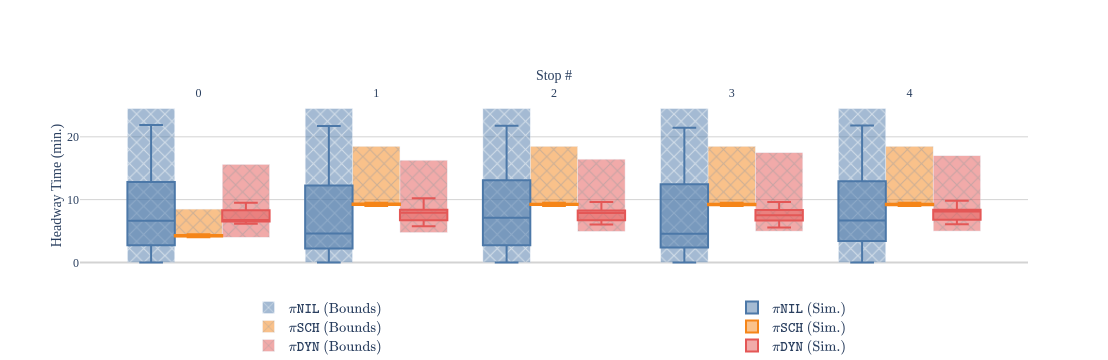

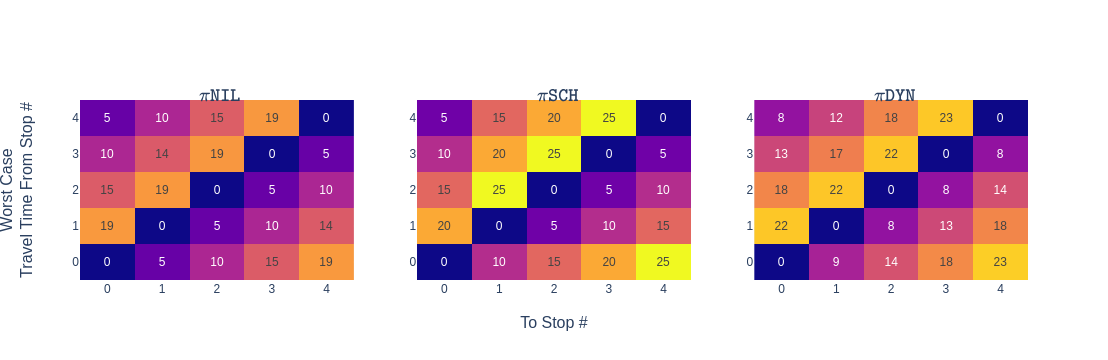

In [8]:
T_MAX = 60 * 24 * 7
N_STOPS = 5
BASE_ROUTE = [
    StopConfig(
        tau=(4, 4.5),
        delta=(0, 0.5),
        policy=BolehPolicy,
        policy_args={},
    ) for _ in range(N_STOPS)
]
START_TIMES = [0, 10, 20]

# Scheduled terminal departure
SCHED_ROUTE = deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    SCHED_ROUTE[i].policy = InfiniteSchedulePolicy
    SCHED_ROUTE[i].policy_args = {'time_delta': 10, 'offset': 30 if i == 0 else 5 * i}

# Headway driven holding
HEADWAY_ROUTE = deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    HEADWAY_ROUTE[i].policy = HeadwayDrivenPolicy
    HEADWAY_ROUTE[i].policy_args = {'activation_ratio': 0.75, 'max_holding': 30}

routes = [
    RouteConfig(name=r'\pi\texttt{NIL}', route=BASE_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{SCH}', route=SCHED_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}', route=HEADWAY_ROUTE, start_times=START_TIMES),
]

run_experiment(exp_id='holdstop01234', routes=routes, t_max=T_MAX)

## Exp 2: Holding Policy Only at the First Stop
Consider the case where only the first stop has holding policy.  This represents the case where buses are released from a terminal and service a circuit ending at the same terminal.

Working on \pi\texttt{NIL}...
Working on \pi\texttt{SCH}...
Working on \pi\texttt{DYN}...


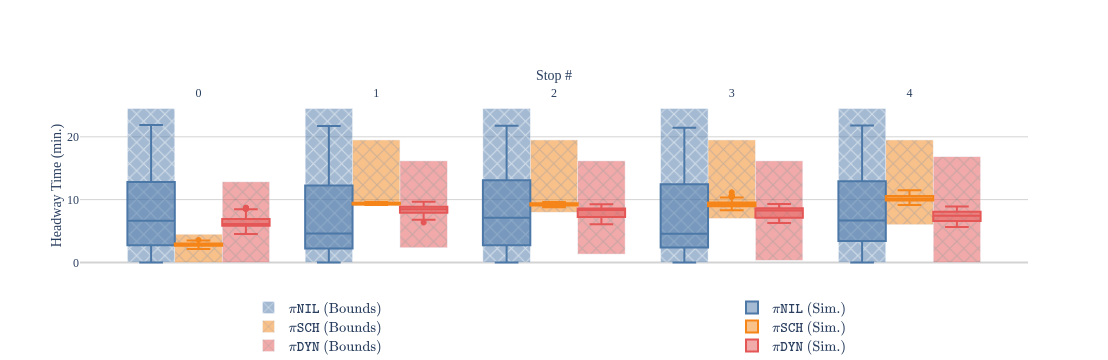

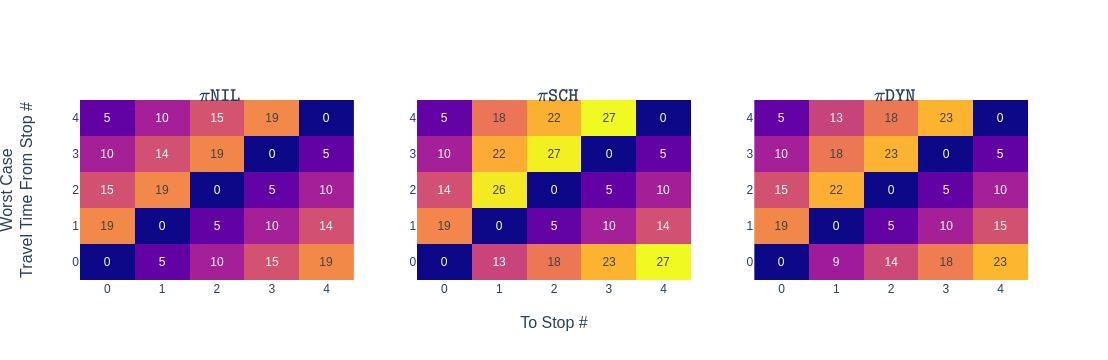

In [9]:
T_MAX = 60 * 24 * 7
N_STOPS = 5
BASE_ROUTE = [
    StopConfig(
        tau=(4, 4.5),
        delta=(0, 0.5),
        policy=BolehPolicy,
        policy_args={},
    ) for _ in range(N_STOPS)
]
START_TIMES = [0, 10, 20]

# Scheduled terminal departure
SCHED_ROUTE = deepcopy(BASE_ROUTE)
SCHED_ROUTE[0].policy = InfiniteSchedulePolicy
SCHED_ROUTE[0].policy_args = {'time_delta': 10, 'offset': 30}

# Headway driven holding
HEADWAY_ROUTE = deepcopy(BASE_ROUTE)
HEADWAY_ROUTE[0].policy = HeadwayDrivenPolicy
HEADWAY_ROUTE[0].policy_args = {'activation_ratio': 0.75, 'max_holding': 30}

routes = [
    RouteConfig(name=r'\pi\texttt{NIL}', route=BASE_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{SCH}', route=SCHED_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}', route=HEADWAY_ROUTE, start_times=START_TIMES),
]

run_experiment(exp_id='holdstop0', routes=routes, t_max=T_MAX)

## Exp 3: Terminal and Midpoint Holding
Consider the case where the first and middle stops are governed by a holding policy.  This represents the case where buses are released from a terminal, travel to another terminal, and then travel back to their originating terminal.

Working on \pi\texttt{SCH}\;@s^{(0)}, s^{(2)}...
Working on \pi\texttt{DYN}\;@s^{(0)}, s^{(2)}...
Working on \pi\texttt{DYN}\;@s^{(0)},\;\pi\texttt{SCH}\;@s^{(2)}...


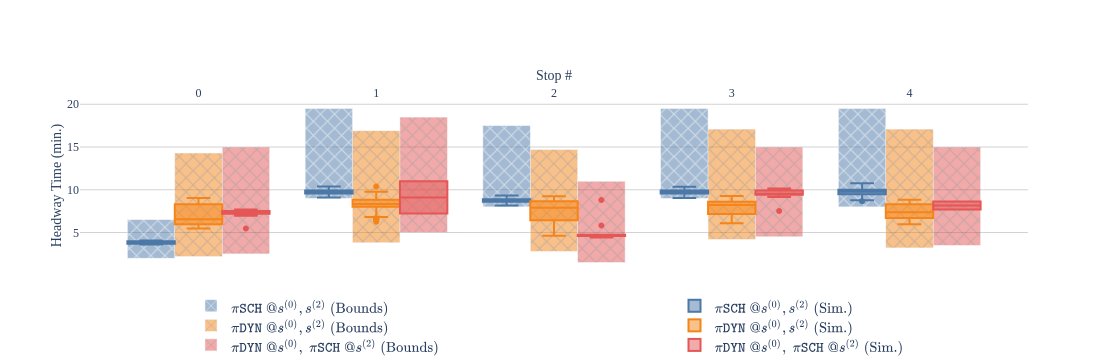

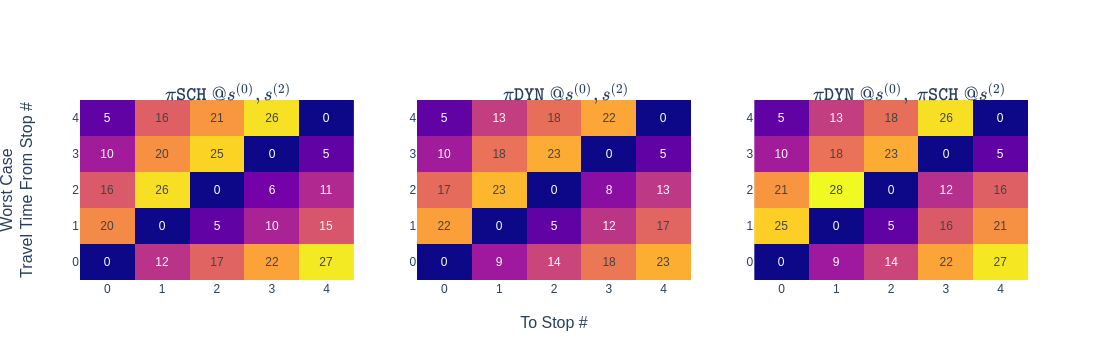

In [10]:
T_MAX = 60 * 24 * 7
N_STOPS = 5
BASE_ROUTE = [
    StopConfig(
        tau=(4, 4.5),
        delta=(0, 0.5),
        policy=BolehPolicy,
        policy_args={},
    ) for _ in range(N_STOPS)
]
START_TIMES = [0, 10, 20]

# Scheduled terminal departure
SCHED_ROUTE = deepcopy(BASE_ROUTE)
SCHED_ROUTE[0].policy = InfiniteSchedulePolicy
SCHED_ROUTE[0].policy_args = {'time_delta': 10, 'offset': 30}
SCHED_ROUTE[2].policy = InfiniteSchedulePolicy
SCHED_ROUTE[2].policy_args = {'time_delta': 10, 'offset': 10}

# Headway driven holding
HEADWAY_ROUTE = deepcopy(BASE_ROUTE)
HEADWAY_ROUTE[0].policy = HeadwayDrivenPolicy
HEADWAY_ROUTE[0].policy_args = {'activation_ratio': 0.75, 'max_holding': 30}
HEADWAY_ROUTE[2].policy = HeadwayDrivenPolicy
HEADWAY_ROUTE[2].policy_args = {'activation_ratio': 0.75, 'max_holding': 30}

# Headway driven holding at initial terminal with scheduled departures at midpoint
HS_ROUTE = deepcopy(BASE_ROUTE)
HS_ROUTE[0].policy = HeadwayDrivenPolicy
HS_ROUTE[0].policy_args = {'activation_ratio': 0.75, 'max_holding': 30}
HS_ROUTE[2].policy = InfiniteSchedulePolicy
HS_ROUTE[2].policy_args = {'time_delta': 10, 'offset': 0}

routes = [
    RouteConfig(name=r'\pi\texttt{SCH}\;@s^{(0)}, s^{(2)}', route=SCHED_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;@s^{(0)}, s^{(2)}', route=HEADWAY_ROUTE, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}\;@s^{(0)},\;\pi\texttt{SCH}\;@s^{(2)}', route=HS_ROUTE, start_times=START_TIMES),
]

run_experiment(exp_id='holdstop02', routes=routes, t_max=T_MAX)

## Exp 4: Hyperparameters of the Headway-Driven Holding Policy
Expore the effects of the headway-driven holding policy's hyperparameters: activation ratio and maximum hold time.

Working on \pi\texttt{DYN}, R=1.00,\Phi=30...
Working on \pi\texttt{DYN}, R=0.75,\Phi=30...
Working on \pi\texttt{DYN}, R=0.50,\Phi=30...
Working on \pi\texttt{DYN}, R=0.25,\Phi=30...
Working on \pi\texttt{DYN}, R=1,\Phi=4...
Working on \pi\texttt{DYN}, R=1,\Phi=3...
Working on \pi\texttt{DYN}, R=1,\Phi=2...


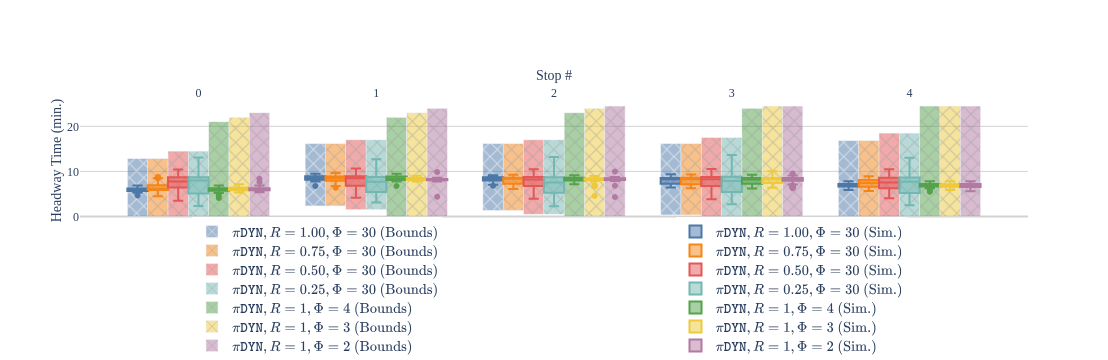

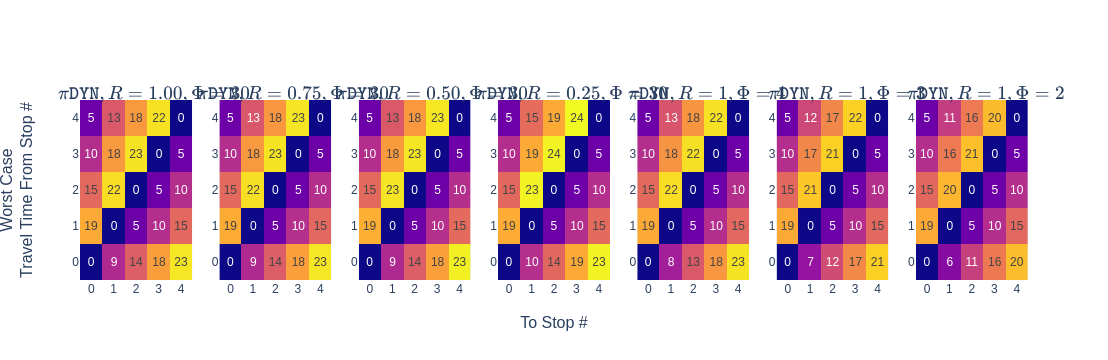

In [11]:
T_MAX = 60 * 24 * 7
N_STOPS = 5
BASE_ROUTE = [
    StopConfig(
        tau=(4, 4.5),
        delta=(0, 0.5),
        policy=BolehPolicy,
        policy_args={},
    ) for _ in range(N_STOPS)
]
START_TIMES = [0, 10, 20]

# Activation ratio: 1, Max holding: 30
ROUTE0 = deepcopy(BASE_ROUTE)
ROUTE0[0].policy = HeadwayDrivenPolicy
ROUTE0[0].policy_args = {'activation_ratio': 1, 'max_holding': 30}

# Activation ratio: 0.75, Max holding: 30
ROUTE1 = deepcopy(BASE_ROUTE)
ROUTE1[0].policy = HeadwayDrivenPolicy
ROUTE1[0].policy_args = {'activation_ratio': 0.75, 'max_holding': 30}

# Activation ratio: 0.50, Max holding: 30
ROUTE2 = deepcopy(BASE_ROUTE)
ROUTE2[0].policy = HeadwayDrivenPolicy
ROUTE2[0].policy_args = {'activation_ratio': 0.50, 'max_holding': 30}

# Activation ratio: 0.25, Max holding: 30
ROUTE3 = deepcopy(BASE_ROUTE)
ROUTE3[0].policy = HeadwayDrivenPolicy
ROUTE3[0].policy_args = {'activation_ratio': 0.25, 'max_holding': 30}

# Activation ratio: 1, Max holding: 4
ROUTE4 = deepcopy(BASE_ROUTE)
ROUTE4[0].policy = HeadwayDrivenPolicy
ROUTE4[0].policy_args = {'activation_ratio': 1, 'max_holding': 4}

# Activation ratio: 1, Max holding: 3
ROUTE5 = deepcopy(BASE_ROUTE)
ROUTE5[0].policy = HeadwayDrivenPolicy
ROUTE5[0].policy_args = {'activation_ratio': 1, 'max_holding': 3}

# Activation ratio: 1, Max holding: 2
ROUTE6 = deepcopy(BASE_ROUTE)
ROUTE6[0].policy = HeadwayDrivenPolicy
ROUTE6[0].policy_args = {'activation_ratio': 1, 'max_holding': 2}

routes = [
    RouteConfig(name=r'\pi\texttt{DYN}, R=1.00,\Phi=30', route=ROUTE0, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}, R=0.75,\Phi=30', route=ROUTE1, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}, R=0.50,\Phi=30', route=ROUTE2, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}, R=0.25,\Phi=30', route=ROUTE3, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}, R=1,\Phi=4', route=ROUTE4, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}, R=1,\Phi=3', route=ROUTE5, start_times=START_TIMES),
    RouteConfig(name=r'\pi\texttt{DYN}, R=1,\Phi=2', route=ROUTE6, start_times=START_TIMES),
]

run_experiment(exp_id='hyperparameters', routes=routes, t_max=T_MAX)

## Exp 5: Number of buses
Expore the effects of different numbers of buses on different holding policies.

Working on \pi\texttt{SCH}\;@s^{(0)}, M=2...
Working on \pi\texttt{DYN}\;@s^{(0)}, M=2...
Working on \pi\texttt{SCH}\;@s^{(0)}, M=3...
Working on \pi\texttt{DYN}\;@s^{(0)}, M=3...
Working on \pi\texttt{SCH}\;@s^{(0)}, M=4...
Working on \pi\texttt{DYN}\;@s^{(0)}, M=4...


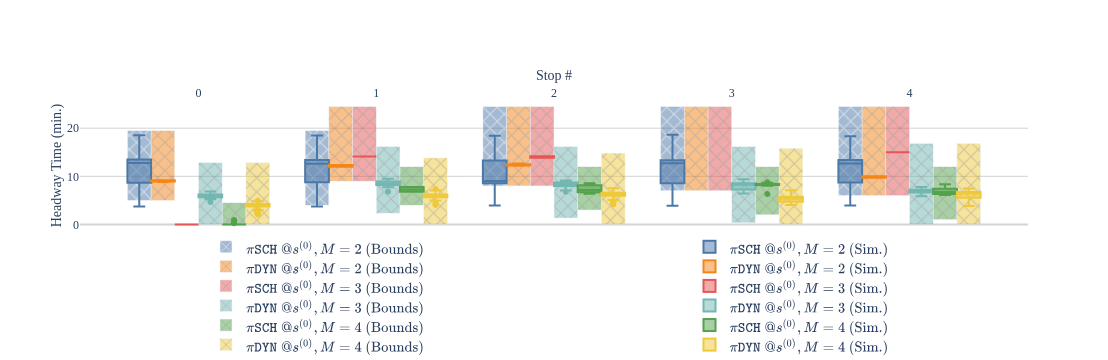

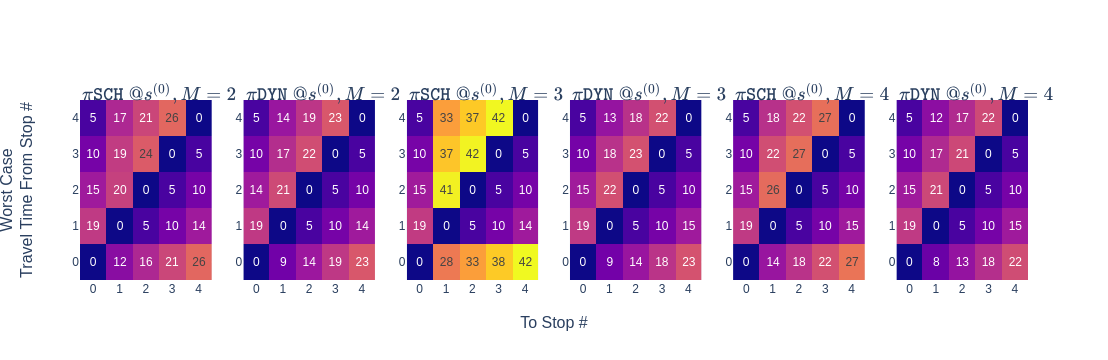

In [12]:
T_MAX = 60 * 24 * 7
N_STOPS = 5
BASE_ROUTE = [
    StopConfig(
        tau=(4, 4.5),
        delta=(0, 0.5),
        policy=BolehPolicy,
        policy_args={},
    ) for _ in range(N_STOPS)
]

# 2 buses
SCHED2BUSES = deepcopy(BASE_ROUTE)
SCHED2BUSES[0].policy = InfiniteSchedulePolicy
SCHED2BUSES[0].policy_args = {'time_delta': 10, 'offset': 30}

# 3 buses
SCHED3BUSES = deepcopy(BASE_ROUTE)
SCHED3BUSES[0].policy = InfiniteSchedulePolicy
SCHED3BUSES[0].policy_args = {'time_delta': 15, 'offset': 30}

# 4 buses
SCHED4BUSES = deepcopy(BASE_ROUTE)
SCHED4BUSES[0].policy = InfiniteSchedulePolicy
SCHED4BUSES[0].policy_args = {'time_delta': 7.5, 'offset': 30}

# Headway-driven route can adapt without schedule change
HEADWAY_ROUTE = deepcopy(BASE_ROUTE)
HEADWAY_ROUTE[0].policy = HeadwayDrivenPolicy
HEADWAY_ROUTE[0].policy_args = {'activation_ratio': 1, 'max_holding': 30}

routes = [
    RouteConfig(name=r'\pi\texttt{SCH}\;@s^{(0)}, M=2', route=SCHED2BUSES, start_times=[0, 15]),
    RouteConfig(name=r'\pi\texttt{DYN}\;@s^{(0)}, M=2', route=HEADWAY_ROUTE, start_times=[0, 15]),
    RouteConfig(name=r'\pi\texttt{SCH}\;@s^{(0)}, M=3', route=SCHED3BUSES, start_times=[0, 10, 20]),
    RouteConfig(name=r'\pi\texttt{DYN}\;@s^{(0)}, M=3', route=HEADWAY_ROUTE, start_times=[0, 10, 20]),
    RouteConfig(name=r'\pi\texttt{SCH}\;@s^{(0)}, M=4', route=SCHED4BUSES, start_times=[7.5, 15, 22.5, 30]),
    RouteConfig(name=r'\pi\texttt{DYN}\;@s^{(0)}, M=4', route=HEADWAY_ROUTE, start_times=[7.5, 15, 22.5, 30]),
]

run_experiment(exp_id='n_buses', routes=routes, t_max=T_MAX)